# 准备数据

In [1]:
# 加载模块
import polars as pl

from vnpy.trader.constant import Interval

from vnpy.alpha import AlphaLab

In [2]:
# 创建数据中心
lab: AlphaLab = AlphaLab("./lab/csi300")

In [3]:
# 设置任务参数
name = "lstm"
index_symbol: str = "000300.SSE"
start: str = "2008-01-01"
end: str = "2020-08-01"
interval: Interval = Interval.DAILY
extended_days: int = 100

In [4]:
# 加载所有成分股代码
component_symbols: list[str] = lab.load_component_symbols(index_symbol, start, end)

# 特征计算

In [5]:
# 加载模块
from datetime import datetime
from functools import partial

from vnpy.trader.constant import Interval

from vnpy.alpha.dataset import (
    AlphaDataset,
    process_drop_na,
    process_robust_zscore_norm,
    process_fill_na,
    process_cs_rank_norm,
    to_datetime
)
from vnpy.alpha.dataset.datasets.alpha_158 import Alpha158


In [6]:
# 加载成分股数据
df: pl.DataFrame = lab.load_bar_df(component_symbols, interval, start, end, extended_days)

In [7]:
# 设置数据时间段
train_period: tuple[str, str] = ("2008-01-01", "2014-12-31")
valid_period: tuple[str, str] = ("2015-01-01", "2016-12-31")
test_period: tuple[str, str] = ("2017-01-01", "2020-8-31")

In [8]:
# 创建数据集对象
dataset: AlphaDataset = Alpha158(
    df,
    train_period=train_period,
    valid_period=valid_period,
    test_period=test_period,
)

In [9]:
# 添加数据预处理器
fit_start_time: datetime = to_datetime(train_period[0])
fit_end_time: datetime = to_datetime(train_period[1])

dataset.add_processor("infer", partial(process_robust_zscore_norm, fit_start_time=fit_start_time, fit_end_time=fit_end_time))
dataset.add_processor("infer", partial(process_fill_na, fill_value=0, fill_label=False))

dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
dataset.add_processor("learn", partial(process_cs_rank_norm, names=["label"]))

In [10]:
# 收集指数成分过滤器
filters: dict[str, list[str]] = lab.load_component_filters(index_symbol, start, end)

In [11]:
# 准备特征和标签数据
dataset.prepare_data(filters, max_workers=4)

# 应用数据预处理器
dataset.process_data()

2026-05-11 14:57:56 开始计算表达式因子特征


100%|████████████████████████████████████████████████████████████████████████████████| 159/159 [47:10<00:00, 17.80s/it]

2026-05-11 15:45:08 开始合并结果数据因子特征



0it [00:00, ?it/s]


2026-05-11 15:45:09 开始筛选成分股数据


100%|███████████████████████████████████████████████████████████████████████████████| 712/712 [00:04<00:00, 149.86it/s]


In [12]:
# 保存到文件缓存
lab.save_dataset(name, dataset)

# 模型训练

In [13]:
# 加载模块
import numpy as np

from vnpy.alpha.dataset import Segment
from vnpy.alpha.model import AlphaModel

from lstm_model import LstmModel

In [14]:
dataset: AlphaDataset = lab.load_dataset(name)

In [15]:
kwargs = {
    "input_size": 158,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.0,
    "n_epochs": 200,
    "lr": 1e-3,
    "early_stop_rounds": 20,
    "batch_size": 800,
    "seed": 42
}

In [16]:
model: AlphaModel = LstmModel(**kwargs)

In [17]:
model.fit(dataset)

2026-05-11 15:46:20 Epoch 0:
2026-05-11 15:46:20 training...
2026-05-11 15:46:27 evaluating...
2026-05-11 15:46:29 train -0.982520, valid -0.989726
2026-05-11 15:46:29 Epoch 1:
2026-05-11 15:46:29 training...
2026-05-11 15:46:35 evaluating...
2026-05-11 15:46:37 train -0.978584, valid -0.994008
2026-05-11 15:46:37 Epoch 2:
2026-05-11 15:46:37 training...
2026-05-11 15:46:43 evaluating...
2026-05-11 15:46:45 train -0.971995, valid -0.995497
2026-05-11 15:46:45 Epoch 3:
2026-05-11 15:46:45 training...
2026-05-11 15:46:51 evaluating...
2026-05-11 15:46:53 train -0.968197, valid -0.998007
2026-05-11 15:46:53 Epoch 4:
2026-05-11 15:46:53 training...
2026-05-11 15:46:59 evaluating...
2026-05-11 15:47:01 train -0.963578, valid -0.999128
2026-05-11 15:47:01 Epoch 5:
2026-05-11 15:47:01 training...
2026-05-11 15:47:07 evaluating...
2026-05-11 15:47:09 train -0.959996, valid -1.002562
2026-05-11 15:47:09 Epoch 6:
2026-05-11 15:47:09 training...
2026-05-11 15:47:15 evaluating...
2026-05-11 15:47:

In [18]:
# 查看模型细节
model.detail()

2026-05-11 15:49:12 输入特征维度: 158
2026-05-11 15:49:12 LSTM隐藏层数量: 2
2026-05-11 15:49:12 每层神经元数量: 64
2026-05-11 15:49:12 模型总参数量: 90,689
2026-05-11 15:49:12 训练设备: cpu
2026-05-11 15:49:12 当前学习率: 0.001
2026-05-11 15:49:12 批次大小: 800


,Importance
Feature,
rank_5,0.001759
imin_10,0.001344
imin_5,0.001183
cord_20,0.001165
rank_10,0.001164
...,...
qtlu_30,0.000281
cntn_10,0.000272
vsumn_5,0.000271


In [19]:
# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_infer(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]

D:\veighna_studio\Lib\site-packages\alphalens\utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
D:\veighna_studio\Lib\site-packages\alphalens\utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
D:\veighna_studio\Lib\site-packages\alphalens\utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retu

Dropped 1.1% entries from factor data: 1.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.514813,-0.007295,-0.180045,0.069160,25830,10.0
2,-0.353785,0.043968,-0.096747,0.048365,25830,10.0
3,-0.304578,0.086975,-0.056859,0.046101,25830,10.0
4,-0.262164,0.124890,-0.026777,0.045074,25830,10.0
5,-0.226685,0.177382,-0.000737,0.044588,25830,10.0
6,-0.202987,0.219605,0.024070,0.044454,25830,10.0
7,-0.166942,0.275038,0.049416,0.044866,25830,10.0
8,-0.135501,0.314305,0.077622,0.045887,25830,10.0
9,-0.096220,0.354264,0.113608,0.048142,25830,10.0


Returns Analysis


,1D,5D,10D
Ann. alpha,0.420,0.235,0.135
beta,0.006,-0.004,-0.030
Mean Period Wise Return Top Quantile (bps),21.346,12.941,8.424
Mean Period Wise Return Bottom Quantile (bps),-16.696,-10.615,-5.575
Mean Period Wise Spread (bps),38.042,23.555,13.999


<Figure size 640x480 with 0 Axes>

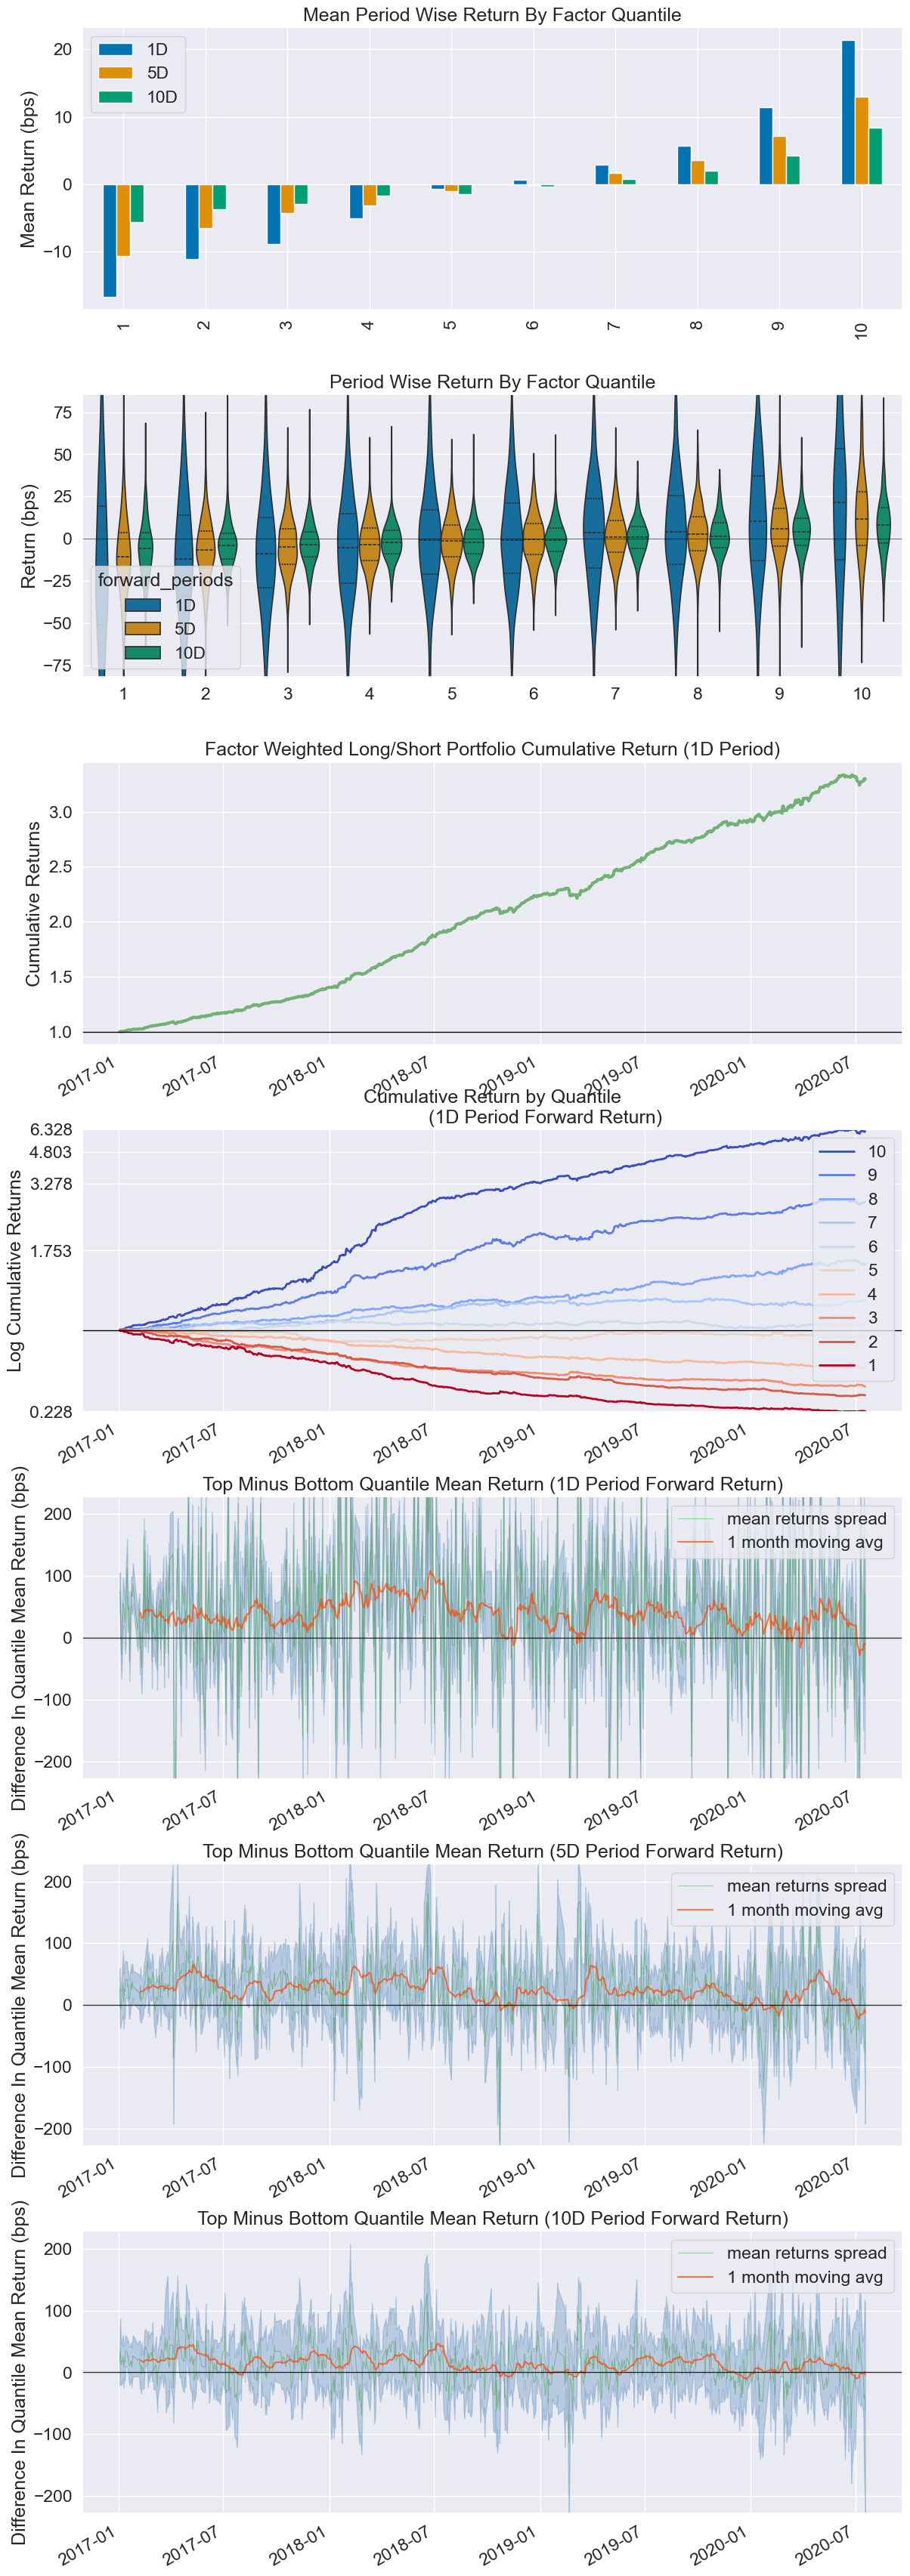

Information Analysis


,1D,5D,10D
IC Mean,0.079,0.092,0.077
IC Std.,0.134,0.129,0.124
Risk-Adjusted IC,0.594,0.710,0.624
t-stat(IC),17.443,20.839,18.303
p-value(IC),0.000,0.000,0.000
IC Skew,0.018,0.046,-0.106
IC Kurtosis,0.495,-0.077,0.119


D:\veighna_studio\Lib\site-packages\alphalens\performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


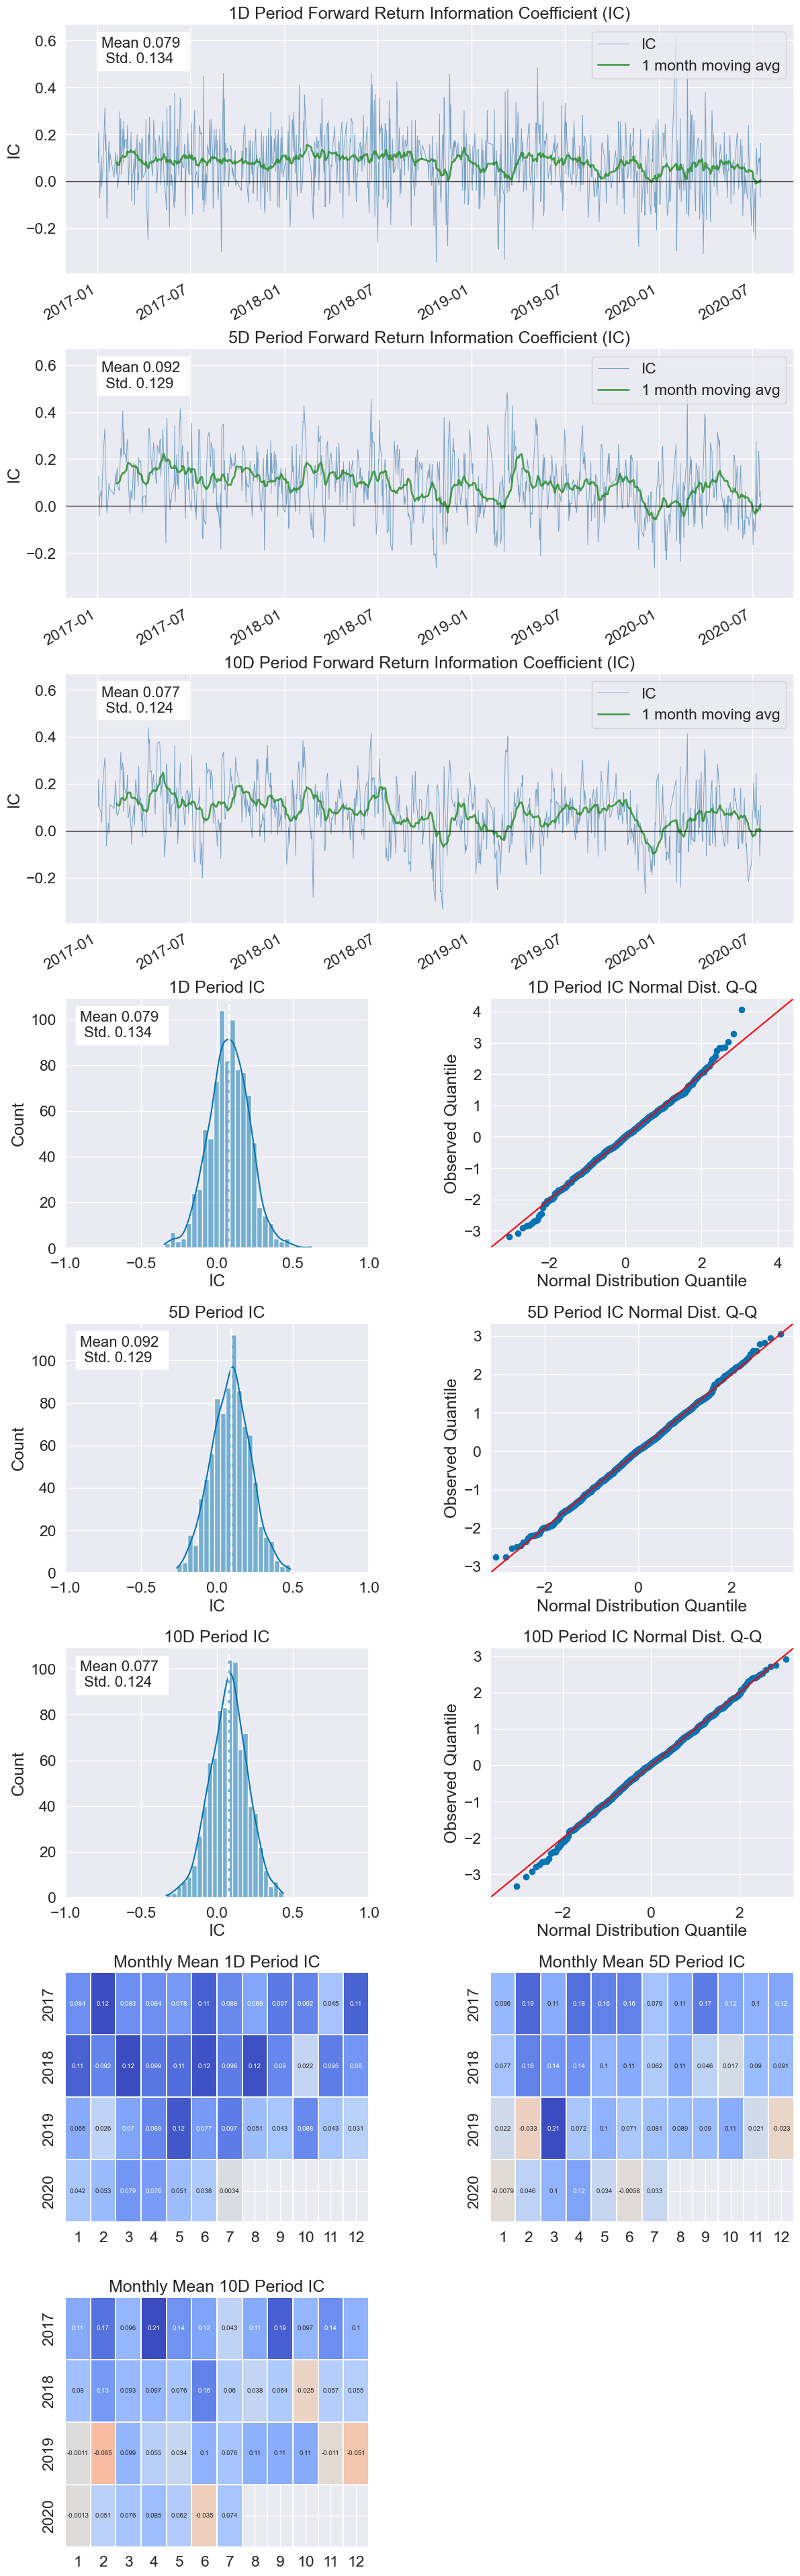

D:\veighna_studio\Lib\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.579,0.785,0.818
Quantile 2 Mean Turnover,0.772,0.859,0.870
Quantile 3 Mean Turnover,0.817,0.875,0.884
Quantile 4 Mean Turnover,0.832,0.881,0.885
Quantile 5 Mean Turnover,0.841,0.885,0.890
Quantile 6 Mean Turnover,0.843,0.885,0.890
Quantile 7 Mean Turnover,0.830,0.877,0.887
Quantile 8 Mean Turnover,0.818,0.869,0.876
Quantile 9 Mean Turnover,0.764,0.857,0.869
Quantile 10 Mean Turnover,0.538,0.789,0.806


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.616,0.235,0.187


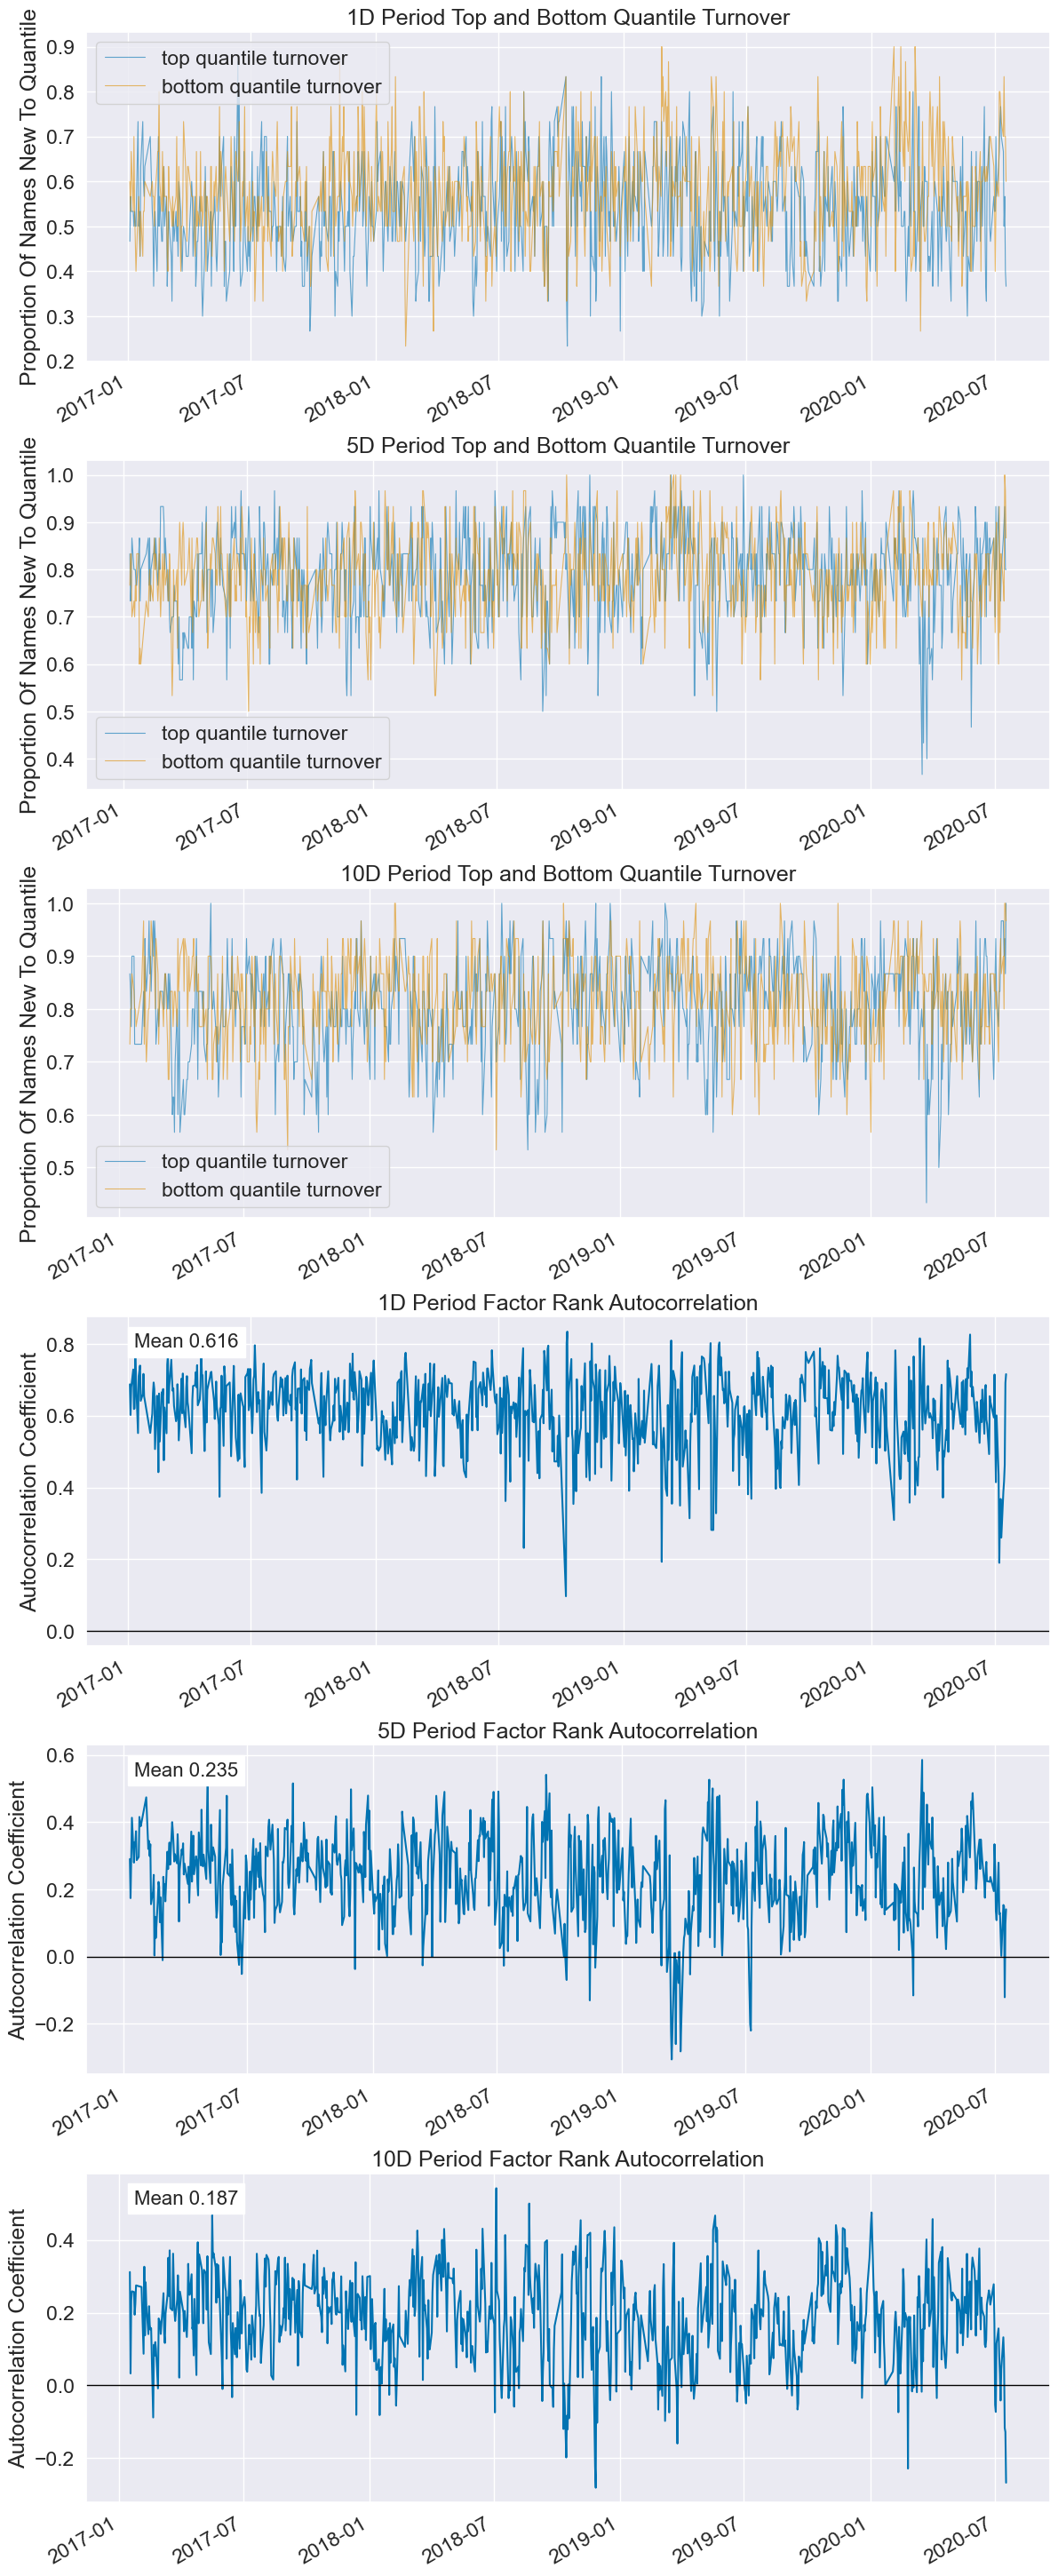

In [20]:
# 检查信号绩效
dataset.show_signal_performance(signal)

In [21]:
# 保存信号数据
lab.save_signal(name, signal)

# 策略回测

In [22]:
# 加载模块
import importlib
from datetime import datetime

from vnpy.alpha.strategy import BacktestingEngine

from vnpy.alpha.strategy.strategies.equity_demo_strategy import EquityDemoStrategy

In [23]:
# 从文件加载信号数据
signal = lab.load_signal(name)

In [24]:
# 创建回测引擎对象
engine = BacktestingEngine(lab)

# 设置回测参数
engine.set_parameters(
    vt_symbols=component_symbols,
    interval=Interval.DAILY,
    start=datetime(2017, 1, 1),
    end=datetime(2020, 8, 1),
    capital=100000000
)

# 添加策略实例
setting = {"top_k": 30, "n_drop": 3, "hold_thresh": 3}
engine.add_strategy(EquityDemoStrategy, setting, signal)

In [25]:
# 执行回测任务
engine.load_data()
engine.run_backtesting()
engine.calculate_result()
engine.calculate_statistics()
engine.show_chart()

2026-05-11 15:49:35 开始加载历史数据


100%|███████████████████████████████████████████████████████████████████████████████| 712/712 [00:05<00:00, 139.20it/s]

2026-05-11 15:49:40 部分合约历史数据为空：['600087.SSE', '600631.SSE', '000527.SZSE', '600786.SSE', '601299.SSE', '600357.SSE', '600591.SSE', '600102.SSE', '601268.SSE', '600832.SSE', '000562.SZSE', '000024.SZSE', '600001.SSE']
2026-05-11 15:49:40 所有历史数据加载完成
2026-05-11 15:49:40 策略初始化完成
2026-05-11 15:49:40 开始回放历史数据


2026-05-11 15:49:46 历史数据回放结束
2026-05-11 15:49:46 开始计算逐日盯市盈亏
2026-05-11 15:49:47 逐日盯市盈亏计算完成
2026-05-11 15:49:47 开始计算策略统计指标
2026-05-11 15:49:47 ------------------------------
2026-05-11 15:49:47 首个交易日：  2017-01-03
2026-05-11 15:49:47 最后交易日：  2020-07-31
2026-05-11 15:49:47 总交易日：  871
2026-05-11 15:49:47 盈利交易日：  489
2026-05-11 15:49:47 亏损交易日：  381
2026-05-11 15:49:47 起始资金：  100,000,000.00
2026-05-11 15:49:47 结束资金：  325,877,863.91
2026-05-11 15:49:47 总收益率：  225.88%
2026-05-11 15:49:47 年化收益：  62.24%
2026-05-11 15:49:47 最大回撤:   -49,649,361.15
2026-05-11 15:49:47 百分比最大回撤: -22.24%
2026-05-11 15:49:47 最长回撤天数:   70
2026-05-11 15:49:47 总盈亏：  225,877,863.91
2026-05-11 15:49:47 总手续费：  23,487,232.25
2026-05-11 15:49:47 总成交金额：  31,341,255,302.96
2026-05-11 15:49:47 总成交笔数：  4696
2026-05-11 15:49:47 日均盈亏：  259,331.65
2026-05-11 15:49:47 日均手续费：  26,965.82
2026-05-11 15:49:47 日均成交金额：  35,983,071.53
2026-05-11 15:49:47 日均成交笔数：  5.39150401836969
2026-05-11 15:49:47 日均收益率：  0.15%
2026-05-11 15:49:47 收益标准差：  

D:\veighna_studio\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning:

urllib3 (2.3.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!



In [26]:
# 显示超额收益分析结果
engine.show_performance(benchmark_symbol=index_symbol)